In [11]:
from langgraph.graph import StateGraph, START, END
from langchain_huggingface import HuggingFaceEndpoint
from typing import TypedDict
from dotenv import load_dotenv
import os

In [12]:
load_dotenv()


True

In [ ]:
# Read key from .env
HF_API_KEY = os.getenv("HF_API_KEY")

# Initialize Hugging Face model
model = HuggingFaceEndpoint(
    repo_id="moonshotai/Kimi-K2-Thinking",
    huggingface_api_key=HF_API_KEY,
    temperature=0.7,
    max_new_tokens=512
)

WARNING! huggingface_api_key is not default parameter.
                    huggingface_api_key was transferred to model_kwargs.
                    Please make sure that huggingface_api_key is what you intended.


In [14]:
class PromptState(TypedDict):
    topic: str
    outline: str
    content: str
    evaluator: str


In [15]:
def generate_outline(state : PromptState) -> PromptState:

    # fetch title/topic
    topic = state['topic']

    # call llm
    prompt = f"""
            create a detailed outline for following topic
            {topic}
            """
    
    outline = model.invoke(prompt).content

    # update state

    state['outline'] = outline


    return state


In [16]:
def generate_blog(state: PromptState) -> PromptState:

    topic = state['topic']
    outline = state['outline']
    
    prompt = f"""
            create a blog for following topic
            {topic} and use detailed outline {outline}
            """
    
    content = model.invoke(prompt).content
    state['content'] = content
    return state


In [17]:
def evalaute(state: PromptState) -> PromptState:
    topic = state['topic']
    outline = state['outline']
    content = state['content']
    
    prompt = f"""
            Evaluate blog{content} and provide rating from 1 to 5. 
            Respond ONLY with a single integer. No explanation
            """
    
    evalauate_value = model.invoke(prompt).content
    state['evaluator'] = evalauate_value
    return state

In [18]:
graph = StateGraph(PromptState)

graph.add_node('generate_outline', generate_outline)
graph.add_node('generate_blog', generate_blog)
graph.add_node('evaluate', evalaute)

graph.add_edge(START, 'generate_outline')
graph.add_edge('generate_outline', 'generate_blog')
graph.add_edge('generate_blog', 'evaluate')
graph.add_edge('evaluate', END)
workflow = graph.compile()

In [19]:
initial_state = {'topic': "Beautiful World"}
final_state = workflow.invoke(initial_state)

print(final_state['evaluator'])

TypeError: InferenceClient.text_generation() got an unexpected keyword argument 'huggingface_api_key'

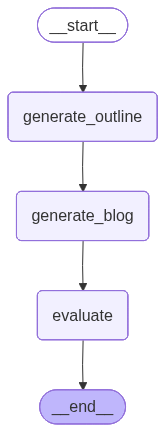

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())